전체 파이프라인 

[1] 전처리 (필터링 + 샘플링)    ← 지금 여기
       ↓
[2] 토크나이저 학습 (SentencePiece, vocab 8K)
       ↓
[3] MLM / NSP 데이터셋 생성
       ↓
[4] BERT 모델 구현
       ↓
[5] Pretrain + 시각화

모델 파라미터 

vocab_size    = 8000
seq_len       = 128
hidden_dim    = 128
num_layers    = 4
num_heads     = 4    (head_dim = 32)
ff_dim        = 512
total params  ≈ 1.83M

### 라이브러리 설치 & 확인

라이브러리 설치 확인과 함께 이번엔 텐서보드를 같이 설치해준다. 
가시화에 도움이 많이 될것 같았기 때문이다. 

In [1]:
%pip install tensorboard

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import importlib

packages = ['sentencepiece', 'numpy', 'pandas', 'tqdm', 'matplotlib', 'tensorboard']
for pkg in packages:
    try:
        m = importlib.import_module(pkg)
        ver = getattr(m, '__version__', 'unknown')
        print(f"✓ {pkg}: {ver}")
    except ImportError:
        print(f"✗ {pkg}: NOT INSTALLED")

✓ sentencepiece: 0.2.1
✓ numpy: 2.4.4
✓ pandas: 3.0.2
✓ tqdm: 4.67.3
✓ matplotlib: 3.10.9
✓ tensorboard: 2.20.0


### EDA&전처리 

항상 파일을 확인하고 나서 전처리를 진행한다. 
이번 데이터셋은 위키의 내용을 그대로 긁어온것 같지만 정리가 잘 되어있었다. 기본적으로 제목+ 내용 형식으로 이뤄져 있었기 때문에 
어떻게 임베딩 모델을 만들어서 학습시켜야 할지도 조금은 감이잡히는 느낌이었다. 

이번엔 전처리까지 빠르게 진행해 주기로 한다. 


In [3]:
from pathlib import Path

KOWIKI_PATH = Path(r"C:\Users\akals\Downloads\kowiki.txt\kowiki.txt")

# 파일 크기를 확인 

size_mb = KOWIKI_PATH.stat().st_size / (1024*1024)
print(f"파일크기 : {size_mb:.1f} MB")

# 초반 부분만  읽어서 간단히 구조파악 

with open(KOWIKI_PATH, 'r', encoding='utf-8') as f:
    head = f.read(5000)

print(repr(head[:2000]))

파일크기 : 635.7 MB
'지미 카터\n제임스 얼 "지미" 카터 주니어(, 1924년 10월 1일 ~ )는 민주당 출신 미국 39번째 대통령 (1977년 ~ 1981년)이다.\n지미 카터는 조지아주 섬터 카운티 플레인스 마을에서 태어났다. 조지아 공과대학교를 졸업하였다. 그 후 해군에 들어가 전함·원자력·잠수함의 승무원으로 일하였다. 1953년 미국 해군 대위로 예편하였고 이후 땅콩·면화 등을 가꿔 많은 돈을 벌었다. 그의 별명이 "땅콩 농부" (Peanut Farmer)로 알려졌다.\n1962년 조지아 주 상원 의원 선거에서 낙선하나 그 선거가 부정선거 였음을 입증하게 되어 당선되고, 1966년 조지아 주 지사 선거에 낙선하지만 1970년 조지아 주 지사를 역임했다. 대통령이 되기 전 조지아주 상원의원을 두번 연임했으며, 1971년부터 1975년까지 조지아 지사로 근무했다. 조지아 주지사로 지내면서, 미국에 사는 흑인 등용법을 내세웠다.\n1976년 대통령 선거에 민주당 후보로 출마하여 도덕주의 정책으로 내세워, 포드를 누르고 당선되었다.\n카터 대통령은 에너지 개발을 촉구했으나 공화당의 반대로 무산되었다.\n카터는 이집트와 이스라엘을 조정하여, 캠프 데이비드에서 안와르 사다트 대통령과 메나헴 베긴 수상과 함께 중동 평화를 위한 캠프데이비드 협정을 체결했다.\n그러나 이것은 공화당과 미국의 유대인 단체의 반발을 일으켰다. 1979년 백악관에서 양국 간의 평화조약으로 이끌어졌다. 또한 소련과 제2차 전략 무기 제한 협상에 조인했다.\n카터는 1970년대 후반 당시 대한민국 등 인권 후진국의 국민들의 인권을 지키기 위해 노력했으며, 취임 이후 계속해서 도덕정치를 내세웠다.\n그러나 주 이란 미국 대사관 인질 사건에서 인질 구출 실패를 이유로 1980년 대통령 선거에서 공화당의 로널드 레이건 후보에게 져 결국 재선에 실패했다. 또한 임기 말기에 터진 소련의 아프가니스탄 침공 사건으로 인해 1980년 하계 올림픽에 반공국가들의 보이콧을 내세웠다.\n지미 카터는 

### 정규식 매칭을 통해서 문장을 나눠봄 

위키디피아 자료라 문장을 나누기가 수월한것 같았다. 
기본적으로ㅗ 정규식을 이용해 ~다. 를 기준으로 문장을 자르는 코드를 만들어서 적용한다. 
간단히 확인해봤는데 자연스럽게 잘리는것 같아서 진행하기로 했다. 

In [4]:
import re 

# 텍스트를 문서 리스트로ㅗ 분리함 각 문서는 제목,내용으로 튜플. 
def parse_documents(text):
    raw_docs = re.split(r'\n\s*\n\s*\n+', text)

    documents = []
    for raw in raw_docs:
        lines = [l.strip() for l in raw.strip().split('\n') if l.strip()]
        if len(lines) < 2 :
            continue
        title = lines[0]
        body = ' '.join(lines[1:])
        documents.append((title, body))
    return documents

# 한국어 문장 분리 정규식 

def split_sentences(text):
    sentences = re.split(r'(?<=[다요까])\.\s+|(?<=[!?])\s+', text)
    return [s.strip() for s in sentences if s.strip()]

#처음 5천자로 테스트 

with open(KOWIKI_PATH, 'r', encoding='utf-8') as f:
    sample = f.read(50000)

docs = parse_documents(sample)
print(f"파싱된 문서 수: {len(docs)}")
print()

#처음 3개 확인해봄 

for i, (title, body) in enumerate(docs[:3]):
    print(f"=== 문서 {i+1}: {title} ===")
    sentences = split_sentences(body)
    print(f"문장 수: {len(sentences)}")
    for j, s in enumerate(sentences[:3]):
        print(f"  [{j+1}] {s[:80]}{'...' if len(s) > 80 else ''}")
    print()

파싱된 문서 수: 22

=== 문서 1: 지미 카터 ===
문장 수: 39
  [1] 제임스 얼 "지미" 카터 주니어(, 1924년 10월 1일 ~ )는 민주당 출신 미국 39번째 대통령 (1977년 ~ 1981년)이다
  [2] 지미 카터는 조지아주 섬터 카운티 플레인스 마을에서 태어났다
  [3] 조지아 공과대학교를 졸업하였다

=== 문서 2: 수학 ===
문장 수: 62
  [1] 수학(數學, )은 양, 구조, 공간, 변화, 미적분 등의 개념을 다루는 학문이다
  [2] 현대 수학은 형식 논리를 이용해서 공리로 구성된 추상적 구조를 연구하는 학문으로 여겨지기도 한다
  [3] 수학은 그 구조와 발전 과정에서는 자연과학에 속하는 물리학을 비롯한 다른 학문들과 깊은 연관을 맺고 있다

=== 문서 3: 수학 상수 ===
문장 수: 5
  [1] 수학에서 상수란 그 값이 변하지 않는 불변량으로, 변수의 반대말이다
  [2] 물리 상수와는 달리, 수학 상수는 물리적 측정과는 상관없이 정의된다
  [3] 수학 상수는 대개 실수체나 복소수체의 원소이다



In [5]:
import re
from collections import Counter
from tqdm import tqdm

def parse_documents_streaming(filepath, max_docs=None):
    buffer = []
    blank_count = 0

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            stripped = line.strip()
            if not stripped:
                blank_count += 1
                if blank_count >= 2 and buffer:

                    lines = [l for l in buffer if l]
                    if len(lines) >= 2:
                        yield lines[0], ' '.join(lines[1:])
                    buffer = []
                    blank_count = 0
            else:
                blank_count = 0
                buffer.append(stripped)
    
        if buffer:
            lines = [l for l in buffer if l]
            if len(lines) >= 2:
                yield lines[0], ' '.join(lines[1:])


SENT_SPLIT = re.compile(r'(?<=[다요까])\.\s+|(?<=[!?])\s+')

def split_sentences(text):
    return [s.strip() for s in SENT_SPLIT.split(text) if s.strip()]


doc_sent_counts = []     
sent_char_lens = []      
total_docs = 0

for title, body in tqdm(parse_documents_streaming(KOWIKI_PATH), desc="Scanning"):
    sentences = split_sentences(body)
    doc_sent_counts.append(len(sentences))
    sent_char_lens.extend(len(s) for s in sentences)
    total_docs += 1

print(f"\n총 문서 수: {total_docs:,}")
print(f"총 문장 수: {len(sent_char_lens):,}")

Scanning: 498143it [00:10, 47135.62it/s]


총 문서 수: 498,143
총 문장 수: 4,340,268


### 시각화 그래프 

이미 먼저 데이터셋을 통해 확인해봤을 때도 그렇지만 짧은 제목-내용의 페이지가 상당수가 존재한다는 점이 특징이었다. 
그래프만 봤을 때는 거의 한 항목에 문장이 2~3문장으로 이뤄진 내용이 거의 25만 정도에 가까워 보였다. 
또한 글자 분포수를 통해서 시퀀스 길이 역시 정할수 있을것 같았다. 

### 모델 전체 파라미터 결정 

후에는 모델에 대한 전체적인 파라미터 설정을 대략적으로 정하는 시간을 가졌다. 
기본적으로 1M이라는 제약이 있기 때문에 거기에 최대한 맞추기 위해서였기도 했다. 



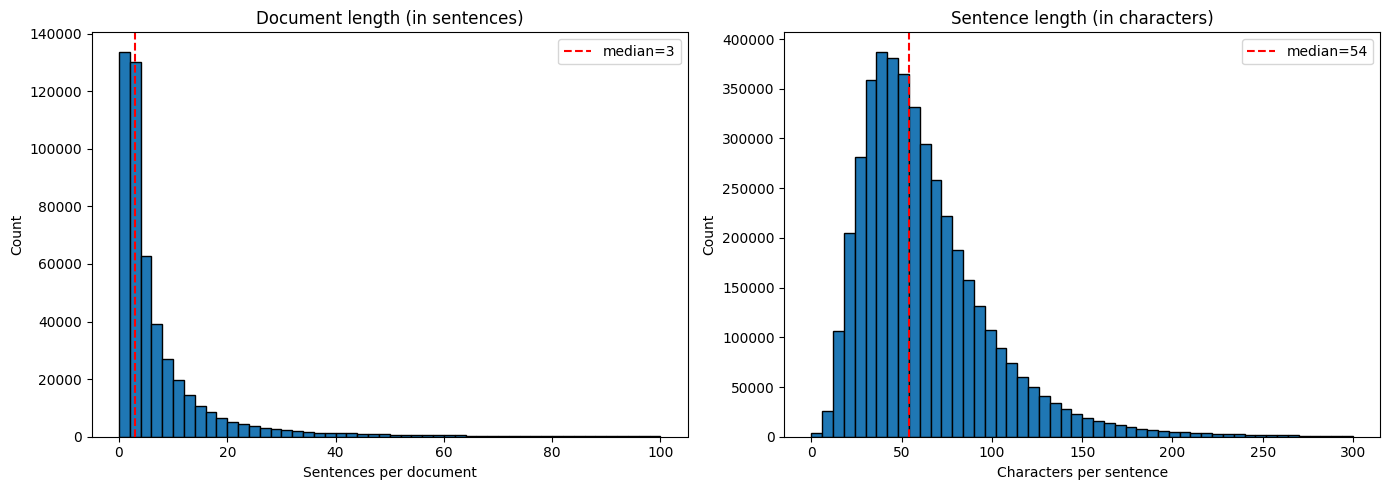

문서당 문장 수:
  median: 3
  90%ile: 18
  99%ile: 91
  max:    1471

문장당 글자 수:
  median: 54
  90%ile: 108
  99%ile: 201
  max:    28193


In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].hist(doc_sent_counts, bins=50, range=(0, 100), edgecolor='black')
axes[0].set_xlabel('Sentences per document')
axes[0].set_ylabel('Count')
axes[0].set_title('Document length (in sentences)')
axes[0].axvline(np.median(doc_sent_counts), color='red', linestyle='--', label=f'median={np.median(doc_sent_counts):.0f}')
axes[0].legend()


axes[1].hist(sent_char_lens, bins=50, range=(0, 300), edgecolor='black')
axes[1].set_xlabel('Characters per sentence')
axes[1].set_ylabel('Count')
axes[1].set_title('Sentence length (in characters)')
axes[1].axvline(np.median(sent_char_lens), color='red', linestyle='--', label=f'median={np.median(sent_char_lens):.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()


print("문서당 문장 수:")
print(f"  median: {np.median(doc_sent_counts):.0f}")
print(f"  90%ile: {np.percentile(doc_sent_counts, 90):.0f}")
print(f"  99%ile: {np.percentile(doc_sent_counts, 99):.0f}")
print(f"  max:    {max(doc_sent_counts)}")
print()
print("문장당 글자 수:")
print(f"  median: {np.median(sent_char_lens):.0f}")
print(f"  90%ile: {np.percentile(sent_char_lens, 90):.0f}")
print(f"  99%ile: {np.percentile(sent_char_lens, 99):.0f}")
print(f"  max:    {max(sent_char_lens)}")

### 데이터 전처리 전 마지막 체크

이번에는 데이터셋의 모든 자료를 쓸 수가 없을 것 같다는 생각을 했기 때문에 문장수 대비 비율을 따로 구해봤다. 
이 값을 통해 깔끔하게 문장수 10이상은 깔끔하게 날려버리기로 한다. 


In [7]:
from collections import Counter

short_counter = Counter(c for c in doc_sent_counts if c <= 15)
total = len(doc_sent_counts)

print(f"{'문장수':>6}  {'문서수':>10}  {'비율':>6}  {'≤이값':>7}  {'>이값':>7}")
print("-" * 50)
cum = 0
for n in sorted(short_counter.keys()):
    cnt = short_counter[n]
    pct = cnt / total * 100
    cum += pct
    remaining = 100 - cum
    print(f"{n:>6}  {cnt:>10,}  {pct:>5.1f}%  {cum:>6.1f}%  {remaining:>6.1f}%")

print(f"\n16문장 이상: {sum(1 for c in doc_sent_counts if c > 15):,}개")

   문장수         문서수      비율      ≤이값      >이값
--------------------------------------------------
     1     133,781   26.9%    26.9%    73.1%
     2      77,513   15.6%    42.4%    57.6%
     3      52,731   10.6%    53.0%    47.0%
     4      35,842    7.2%    60.2%    39.8%
     5      26,880    5.4%    65.6%    34.4%
     6      21,296    4.3%    69.9%    30.1%
     7      17,769    3.6%    73.4%    26.6%
     8      14,517    2.9%    76.3%    23.7%
     9      12,649    2.5%    78.9%    21.1%
    10      10,531    2.1%    81.0%    19.0%
    11       9,202    1.8%    82.8%    17.2%
    12       7,784    1.6%    84.4%    15.6%
    13       6,643    1.3%    85.7%    14.3%
    14       5,828    1.2%    86.9%    13.1%
    15       4,932    1.0%    87.9%    12.1%

16문장 이상: 60,245개


### 필터링 

우선 문장분리를 다 요까로 한건 이번엔 위키피디아의 문서였기 때문에 문장구조자체서 획일화 되어있었기 때문이다. 
하지만 위키디피아 특성상 .를 많이 쓰기 때문에 이걸로 종결어미를 만든다면 오히려 문장분리가 제대로 안될 가능성이 높았을테니까 이 부분은 쓰지 않는다. 

문서분리는 빈줄 2개 이상으로 구분을 지었는데 데이터셋이 문서당 빈줄을 통해서 구분했기 때문이다. 

누적 분포에서 10문장 이후로 각 문장 수당 점유율이 1% 정도로 떨어진다. 
또한 11문장 이상이면 NSP pair를 최대 10개까지 뽑을 수 있어 학습 데이터 다양성에도 충분.

데이터가 충분히 많아 일부를 버려도 1M 모델 학습엔 차고 넘침.


In [8]:
import re
from pathlib import Path
from tqdm import tqdm

KOWIKI_PATH = Path(r"C:\Users\akals\Downloads\kowiki.txt\kowiki.txt")
MIN_SENTENCES = 11   

SENT_SPLIT = re.compile(r'(?<=[다요까])\.\s+|(?<=[!?])\s+')

def split_sentences(text):
    return [s.strip() for s in SENT_SPLIT.split(text) if s.strip()]


def parse_documents_streaming(filepath):
    buffer = []
    blank_count = 0
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            stripped = line.strip()
            if not stripped:
                blank_count += 1
                if blank_count >= 2 and buffer:
                    lines = [l for l in buffer if l]
                    if len(lines) >= 2:
                        yield lines[0], ' '.join(lines[1:])
                    buffer = []
                    blank_count = 0
            else:
                blank_count = 0
                buffer.append(stripped)
        if buffer:
            lines = [l for l in buffer if l]
            if len(lines) >= 2:
                yield lines[0], ' '.join(lines[1:])


documents = []  
total_seen = 0
total_kept = 0

for title, body in tqdm(parse_documents_streaming(KOWIKI_PATH), desc="Filtering"):
    total_seen += 1
    sentences = split_sentences(body)
    if len(sentences) >= MIN_SENTENCES:
        documents.append(sentences)
        total_kept += 1

print(f"\n전체 문서: {total_seen:,}")
print(f"필터링 후: {total_kept:,} ({total_kept/total_seen*100:.1f}%)")
print(f"총 문장 수: {sum(len(d) for d in documents):,}")
print(f"평균 문장/문서: {sum(len(d) for d in documents) / len(documents):.1f}")

Filtering: 498143it [00:10, 46574.07it/s]


전체 문서: 498,143
필터링 후: 94,634 (19.0%)
총 문장 수: 3,028,054
평균 문장/문서: 32.0


### 토크나이저 학습 준비 

토크나이저 학습용으로 전체 문장 3백만에서 50만 정도의 문장만을 무작위로 샘플링 한다. 

3백만의 문장을 전부 돌리면 모델 학습시간이 오래 걸리고 보캡 사이즈8k 기준으로 50만 정도면 충분하다고 생각했기 때문이다. 
랜덤시드를 둔건 나중에 다시 돌려도 같은 샘플링 결과가 나오게 하기 위해서영ㅆ다. 

저장형식은 한 줄에 한 문장씩 넣었는데 이건 SentencePiece가 입력을 '한 줄 = 한 문장'으로 받기 때문이다.



In [9]:
import random
from pathlib import Path

random.seed(42)  

# 작업 디렉토리 만들기 (없으면)
WORK_DIR = Path("./bert_mini")
WORK_DIR.mkdir(exist_ok=True)

# 토크나이저 학습용: 50만 문장 샘플링
TOKENIZER_TRAIN_PATH = WORK_DIR / "spm_train_corpus.txt"
SAMPLE_SIZE = 500_000

# 모든 문장을 flat list로 펼치고 샘플링
all_sentences = [s for doc in documents for s in doc]
print(f"전체 문장 풀: {len(all_sentences):,}")

sampled = random.sample(all_sentences, min(SAMPLE_SIZE, len(all_sentences)))
print(f"샘플링: {len(sampled):,}")

# 한 줄에 한 문장씩 저장
with open(TOKENIZER_TRAIN_PATH, 'w', encoding='utf-8') as f:
    for s in sampled:
        f.write(s + '\n')

# 파일 크기 확인
size_mb = TOKENIZER_TRAIN_PATH.stat().st_size / (1024 * 1024)
print(f"저장 완료: {TOKENIZER_TRAIN_PATH} ({size_mb:.1f} MB)")

전체 문장 풀: 3,028,054
샘플링: 500,000
저장 완료: bert_mini\spm_train_corpus.txt (75.9 MB)


### SentencePiece 학습
vocab size = 8천 
mode type = bpe 
pad id = 0 
시작 토큰 = [CLS]
종결 토큰 = [SEP]

보캡 사이즈의 8천은 1M에 맞추기 위한 제약이었다. 
BPE를 쓰는 것 역시 노드명세를 따라가다보니 그렇게 되었다 
원래는 wordpiece를 쓰는걸로 알고 있었지만 큰 차이는 그렇게 없다고 판단했기 때문에 이대로 진행을 했다. 
하지만 BPE와 WordPiece에서 출력형식은 조금 차이가 많이 나긴 한다. 

Bpe는 __word, sub 지만 WordPiece는 word, ##sub라는 차이가 있음 
합치는 기준도 조금 차이가 난다. BPE는 빈도가 가장 높은 페어를 합치지만 WordPiece는 likelihood가 가장 높아지는 페어를 합친다고 한다. 둘 다 자주 같이 나오는 글자들을 묶어 하나의 토큰으로 만든다는 공통점은 같다. 


character_coverage=0.9995 같은 경우는 좀 특이한 코드인데 학습 코퍼스에서 등장하는 글자의 99.95%를 보캡에 포함 시키고 0.05%를 [UNK]로 처리하는 것이다. 
이는 보캡 사이즈에 맞추기 위해 의도적인 다운사이징을 하게 된 결과였다. 한국어는 단어수가 많기도 하고 희귀단어보다는 자주 쓰는 단어 위주로 챙기는 것이 조금 더 이득이라 봤기 때문이다. 

BERT 학습 코드는 PAD가 0번이라는 가정에 깔려있다. SentencePiece에 그대로 맡기면 다른 ID가 배정될 수 있어 충돌이 생긴다. 명시적으로 박아서 안전 확보. [CLS]/[SEP]도 BERT 관행에 맞춘 이름 변경, [MASK]는 MLM에 필수라 user_defined로 추가.




In [ ]:
import sentencepiece as spm
from pathlib import Path

WORK_DIR = Path("./bert_mini")
TOKENIZER_TRAIN_PATH = WORK_DIR / "spm_train_corpus.txt"
TOKENIZER_PREFIX = WORK_DIR / "spm_ko"   

spm.SentencePieceTrainer.train(
    input=str(TOKENIZER_TRAIN_PATH),
    model_prefix=str(TOKENIZER_PREFIX),
    vocab_size=8000,
    model_type='bpe',           
    character_coverage=0.9995,  
    
    # BERT 특수 토큰
    pad_id=0,  pad_piece='[PAD]',
    unk_id=1,  unk_piece='[UNK]',
    bos_id=2,  bos_piece='[CLS]',
    eos_id=3,  eos_piece='[SEP]',
    user_defined_symbols=['[MASK]'],
    
    # 학습 옵션
    max_sentence_length=4192,
    num_threads=8,
    train_extremely_large_corpus=False,
)

print("\n토크나이저 학습 완료!")
print(f"  모델: {TOKENIZER_PREFIX}.model")
print(f"  vocab: {TOKENIZER_PREFIX}.vocab")


토크나이저 학습 완료!
  모델: bert_mini\spm_ko.model
  vocab: bert_mini\spm_ko.vocab


### 토크나이저 학습 검증 

입력 문장이 어떻게 토큰으로 쪼개지는지 확인하는 단계.
이 단계를 건너뛰면 나중에 학습 시 오류가 생겼을 때 어디서 꼬였는지 귀납적으로 추적하기 어렵기 때문이었다. 

확인한 항모고은 보캡 사이즈와 특수토큰의 위치 그리고 한국어 토큰화가 어떻게 되었는지 입력문장과 직접 비교를 해본다. 
어렵습니다 >> ["▁어렵", "습니다"] 어간과 어미로 분리가 되었고 단어 경계처럼 의미다ㅏㄴ위가 잘 보존 되었다. 


In [11]:
sp = spm.SentencePieceProcessor()
sp.load(f"{TOKENIZER_PREFIX}.model")

print(f"Vocab size: {sp.get_piece_size()}")
print(f"PAD: {sp.pad_id()}, UNK: {sp.unk_id()}")
print(f"[CLS]: {sp.piece_to_id('[CLS]')}")
print(f"[SEP]: {sp.piece_to_id('[SEP]')}")
print(f"[MASK]: {sp.piece_to_id('[MASK]')}")
print()

# 실제 한국어 토큰화 결과
test_sentences = [
    "안녕하세요 반갑습니다",
    "BERT는 양방향 언어 모델입니다.",
    "한국어 자연어 처리는 어렵습니다.",
    "민옥이 AIFFEL에서 공부하고 있다.",
]

for s in test_sentences:
    pieces = sp.encode_as_pieces(s)
    ids = sp.encode_as_ids(s)
    print(f"입력: {s}")
    print(f"  pieces: {pieces}")
    print(f"  ids:    {ids}")
    print()

Vocab size: 8000
PAD: 0, UNK: 1
[CLS]: 2
[SEP]: 3
[MASK]: 4

입력: 안녕하세요 반갑습니다
  pieces: ['▁안', '녕', '하', '세', '요', '▁반', '갑', '습니다']
  ids:    [169, 4773, 3814, 3891, 3972, 126, 4399, 2165]

입력: BERT는 양방향 언어 모델입니다.
  pieces: ['▁B', 'E', 'R', 'T', '는', '▁양', '방', '향', '▁언어', '▁모델', '입', '니다', '.']
  ids:    [435, 4129, 4152, 4082, 3813, 217, 3943, 4087, 1687, 1300, 4006, 1043, 3917]

입력: 한국어 자연어 처리는 어렵습니다.
  pieces: ['▁한국', '어', '▁자연', '어', '▁처', '리는', '▁어렵', '습니다', '.']
  ids:    [366, 3841, 1123, 3841, 266, 335, 3093, 2165, 3917]

입력: 민옥이 AIFFEL에서 공부하고 있다.
  pieces: ['▁민', '옥', '이', '▁A', 'I', 'F', 'F', 'E', 'L', '에서', '▁공부', '하고', '▁있다', '.']
  ids:    [302, 4357, 3809, 319, 4103, 4099, 4099, 4129, 4163, 8, 3142, 44, 26, 3917]



### NSP pair 생성기 
NSP 다음문장을 판별하는 학습 데이터들을 만든다. 
문장관계 이해능력을 학습하기 위해 BERT에서 쓰는 방법이다. 

같은 위키 문서에서 연속된 문장을 만들고 추가로 전혀 다른 문서의 조합도 만들어야 한다. 
비율은 Positive : Negative = 5:5로 맞춘다. 
한쪽으로 치우치면 모델이 다수 클래스로 찍기만 하고 진짜 관계는 안 배우기 때문이다.
문서당 5개로 제한이 되는데 이는 모든 문서가 공평하게 학습 기회를 가지기 위해서이기도 하다. 


In [ ]:
import random

random.seed(42)

def create_nsp_pairs(documents, num_pairs=None):

    pairs = []
    num_docs = len(documents)
    
    for doc_idx, doc in enumerate(documents):
        if len(doc) < 2:
            continue
        

        max_pairs_per_doc = min(len(doc) - 1, 5)
        
        for _ in range(max_pairs_per_doc):
            # 시작 위치 무작위
            i = random.randint(0, len(doc) - 2)
            sent_a = doc[i]
            
            if random.random() < 0.5:
                # Positive: 다음 문장
                sent_b = doc[i + 1]
                is_next = 1
            else:
                # Negative: 다른 문서의 무작위 문장
                while True:
                    other_doc_idx = random.randint(0, num_docs - 1)
                    if other_doc_idx != doc_idx:
                        break
                other_doc = documents[other_doc_idx]
                j = random.randint(0, len(other_doc) - 1)
                sent_b = other_doc[j]
                is_next = 0
            
            pairs.append({
                'sent_a': sent_a,
                'sent_b': sent_b,
                'is_next': is_next,
            })
            
            if num_pairs is not None and len(pairs) >= num_pairs:
                return pairs
    
    return pairs


# 작은 단위로 시험: 처음 100문서로 시작해서 결과 보기
test_pairs = create_nsp_pairs(documents[:100], num_pairs=20)

# positive/negative 비율 확인
pos = sum(1 for p in test_pairs if p['is_next'] == 1)
neg = sum(1 for p in test_pairs if p['is_next'] == 0)
print(f"Total: {len(test_pairs)}, Positive: {pos}, Negative: {neg}")
print()

# 샘플 3개 출력
for i, p in enumerate(test_pairs[:3]):
    label = "IsNext" if p['is_next'] else "NotNext"
    print(f"=== Pair {i+1} [{label}] ===")
    print(f"A: {p['sent_a'][:80]}{'...' if len(p['sent_a']) > 80 else ''}")
    print(f"B: {p['sent_b'][:80]}{'...' if len(p['sent_b']) > 80 else ''}")
    print()

Total: 20, Positive: 11, Negative: 9

=== Pair 1 [IsNext] ===
A: 대통령이 되기 전 조지아주 상원의원을 두번 연임했으며, 1971년부터 1975년까지 조지아 지사로 근무했다
B: 조지아 주지사로 지내면서, 미국에 사는 흑인 등용법을 내세웠다

=== Pair 2 [IsNext] ===
A: 또한 임기 말기에 터진 소련의 아프가니스탄 침공 사건으로 인해 1980년 하계 올림픽에 반공국가들의 보이콧을 내세웠다
B: 지미 카터는 대한민국과의 관계에서도 중요한 영향을 미쳤던 대통령 중 하나다

=== Pair 3 [NotNext] ===
A: 조지아 주지사로 지내면서, 미국에 사는 흑인 등용법을 내세웠다
B: 전하와 스핀이 없는 입자의 운동량 연산자는 다음과 같다



In [13]:
# 전체 문서로 NSP pair 생성
all_pairs = create_nsp_pairs(documents)

# 통계
pos = sum(1 for p in all_pairs if p['is_next'] == 1)
neg = sum(1 for p in all_pairs if p['is_next'] == 0)
total = len(all_pairs)
print(f"총 pair 수: {total:,}")
print(f"  Positive: {pos:,} ({pos/total*100:.1f}%)")
print(f"  Negative: {neg:,} ({neg/total*100:.1f}%)")

총 pair 수: 473,170
  Positive: 236,844 (50.1%)
  Negative: 236,326 (49.9%)


### MLM마스킹
여기서는 2가지의 작업을 한다. 
하나는 마스킹을 하는 함수를 만들고 나머지는 마스킹이 제대로 작동하는지 확인하는 코드이다. 
마스킹 방식은 3가지 정도로 나뉜다. 

우선 기본적으로 마스킹은 15%확률로 랜덤으로 마스킹을 씌우게 된다. 여기서 마스킹을 씌울 시 방식이 3가지로 나뉘는데 
하나는 마스킹 태그를 씌우고, 다른 하나는 랜덤한 토큰으로 바꾸고, 마지막은 원본을 그대로 유지한다.
이는 모델이 MASK 태그 위치만 보고 나머지는 통과시키지 않게 하기 위해서다. 
만약 모델이 마스킹 위치만 신경쓰지 않게 하기위해 마스크 된 태그로만 학습하게 되면 마스킹 된 문장에서만 생각을 하게 되기 때문이다. 
결국 모든 문장에 대해 항상 생각을 하게 하기 위해서 라고 생각된다. 



In [ ]:
import random

def create_mlm_inputs(token_ids, vocab_size, special_token_ids, mask_token_id, mask_prob=0.15):
    masked_ids = list(token_ids)
    labels = [-100] * len(token_ids)
    
    for i, tid in enumerate(token_ids):
        # 특수 토큰은 건너뜀
        if tid in special_token_ids:
            continue
        
        # 15% 확률로 마스킹 대상 선택
        if random.random() < mask_prob:
            labels[i] = tid  # 원본 토큰을 라벨로 보존
            
            r = random.random()
            if r < 0.8:
                # 80%: [MASK]로 교체
                masked_ids[i] = mask_token_id
            elif r < 0.9:
                # 10%: 랜덤 토큰으로 교체 (특수 토큰 제외)
                while True:
                    rand_id = random.randint(0, vocab_size - 1)
                    if rand_id not in special_token_ids:
                        break
                masked_ids[i] = rand_id
            # else 10%: 원본 유지 (이미 그대로니까 아무것도 안 함)
    
    return masked_ids, labels


# 간단 테스트
import sentencepiece as spm
sp = spm.SentencePieceProcessor()
sp.load("./bert_mini/spm_ko.model")

VOCAB_SIZE = sp.get_piece_size()
SPECIAL_IDS = {sp.pad_id(), sp.unk_id(), sp.piece_to_id('[CLS]'), 
               sp.piece_to_id('[SEP]'), sp.piece_to_id('[MASK]')}
MASK_ID = sp.piece_to_id('[MASK]')

# 테스트 문장
test = "BERT는 양방향 언어 모델이고 마스킹을 통해 학습합니다."
ids = [sp.piece_to_id('[CLS]')] + sp.encode_as_ids(test) + [sp.piece_to_id('[SEP]')]

random.seed(42)
masked, labels = create_mlm_inputs(ids, VOCAB_SIZE, SPECIAL_IDS, MASK_ID)

# 결과 비교
print("원본:")
for tid in ids:
    print(f"  {sp.id_to_piece(tid):>10}", end="")
print()
print("마스킹 후:")
for tid in masked:
    print(f"  {sp.id_to_piece(tid):>10}", end="")
print()
print("라벨 (마스킹된 위치만):")
for i, label in enumerate(labels):
    if label != -100:
        print(f"  pos {i}: {sp.id_to_piece(label)} → {sp.id_to_piece(masked[i])}")

원본:
       [CLS]          ▁B           E           R           T           는          ▁양           방           향         ▁언어         ▁모델          이고          ▁마           스           킹           을         ▁통해          ▁학           습           합          니다           .       [SEP]
마스킹 후:
       [CLS]          ▁B      [MASK]           R           T           는          ▁양      [MASK]      [MASK]         ▁언어      [MASK]          이고          ▁마           스           킹           을           訓          ▁학           습           합          니다      [MASK]       [SEP]
라벨 (마스킹된 위치만):
  pos 2: E → [MASK]
  pos 7: 방 → [MASK]
  pos 8: 향 → [MASK]
  pos 10: ▁모델 → [MASK]
  pos 16: ▁통해 → 訓
  pos 21: . → [MASK]


### 데이터셋 로드
지금까지의 재료들을 모델입력 덩어리로 조립하는 단계다. NSP, 토크나이저, 마스킹 함수를 통해 데이터셋을 만들고 그것을 로드할 준비를 한다. 

파이토치에는 데이터 로더라는 도구가 있다. 
배치로 묶어주고 GPU로 옮기고 빨르게 로드해주는 것까지의 기능이 있음 
총 샘플의 갯수     def __len__(self), 와 def __getitem__(self, idx)를 사용해서 샘플을 꺼내오는 것을 정의하고 나면 데이터로더가 알아서 데이터를 로드해서 작업을 시작한다. 

input_ids > 모델 입력 토큰 ID들이다. 
segment_ids >  문장을 구분하는 ID이다 이 토큰이 어느 문장에서 왔는지 확인하는 용도 
attention_mask > 실제 토큰과 패딩을 구분하는 용도 >
mlm_labels > MLM의 정답이다. 마스킹된 원본의 ID를 저장한다. 
nsp_label > NSP의 정답이다 0또는 1 

조립

토큰화 > 길이맞춤 > 시작과 끝 특수태그 삽입 > MLM마스킹 > 패딩을 채우기 > 텐서 변환 

dynamic masking > 같은 짝이어도 에폭마다 다른 마스킹 패턴이 나온다. getitem이 호출될때마다 새로운 마스킹이 일어나기 때문임 

In [ ]:
import torch
from torch.utils.data import Dataset
import random

class BERTPretrainDataset(Dataset):
    
    def __init__(self, pairs, tokenizer, max_seq_len=128, mask_prob=0.15):
        self.pairs = pairs
        self.sp = tokenizer
        self.max_seq_len = max_seq_len
        self.mask_prob = mask_prob
        
        # 특수 토큰 ID 미리 저장
        self.cls_id = tokenizer.piece_to_id('[CLS]')
        self.sep_id = tokenizer.piece_to_id('[SEP]')
        self.pad_id = tokenizer.pad_id()
        self.mask_id = tokenizer.piece_to_id('[MASK]')
        self.vocab_size = tokenizer.get_piece_size()
        
        self.special_ids = {
            self.cls_id, self.sep_id, self.pad_id, 
            self.mask_id, tokenizer.unk_id()
        }
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        pair = self.pairs[idx]
        
        # 1. 두 문장 토큰화
        tokens_a = self.sp.encode_as_ids(pair['sent_a'])
        tokens_b = self.sp.encode_as_ids(pair['sent_b'])
        
        # 2. 길이 맞추기 (truncation)
        # [CLS] A [SEP] B [SEP] = max_seq_len 이내
        # 특수 토큰 3개 차감
        max_content = self.max_seq_len - 3
        while len(tokens_a) + len(tokens_b) > max_content:
            # 긴 쪽을 줄임
            if len(tokens_a) > len(tokens_b):
                tokens_a.pop()
            else:
                tokens_b.pop()
        
        # 3. 시퀀스 조립
        input_ids = [self.cls_id] + tokens_a + [self.sep_id] + tokens_b + [self.sep_id]
        segment_ids = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
        
        # 4. MLM 마스킹
        input_ids, mlm_labels = create_mlm_inputs(
            input_ids, self.vocab_size, self.special_ids, 
            self.mask_id, self.mask_prob
        )
        
        # 5. Padding (max_seq_len까지)
        pad_len = self.max_seq_len - len(input_ids)
        attention_mask = [1] * len(input_ids) + [0] * pad_len
        input_ids = input_ids + [self.pad_id] * pad_len
        segment_ids = segment_ids + [0] * pad_len
        mlm_labels = mlm_labels + [-100] * pad_len
        
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'segment_ids': torch.tensor(segment_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'mlm_labels': torch.tensor(mlm_labels, dtype=torch.long),
            'nsp_label': torch.tensor(pair['is_next'], dtype=torch.long),
        }


# Dataset 생성 및 한 샘플 확인
dataset = BERTPretrainDataset(all_pairs, sp, max_seq_len=128)
print(f"Dataset 크기: {len(dataset):,}")
print()

sample = dataset[0]
for k, v in sample.items():
    print(f"{k}: shape {tuple(v.shape) if v.dim() > 0 else 'scalar'}, dtype {v.dtype}")
print()

# 첫 샘플 내용 디코드
print(f"NSP 라벨: {sample['nsp_label'].item()}")
print(f"실제 길이 (attention_mask 합): {sample['attention_mask'].sum().item()}")
print(f"마스킹된 위치 수: {(sample['mlm_labels'] != -100).sum().item()}")
print()
print("Input tokens:")
for i, tid in enumerate(sample['input_ids'][:30].tolist()):
    seg = sample['segment_ids'][i].item()
    print(f"  [{i:>3}] seg={seg}  {sp.id_to_piece(tid)}")

Dataset 크기: 473,170

input_ids: shape (128,), dtype torch.int64
segment_ids: shape (128,), dtype torch.int64
attention_mask: shape (128,), dtype torch.int64
mlm_labels: shape (128,), dtype torch.int64
nsp_label: shape scalar, dtype torch.int64

NSP 라벨: 0
실제 길이 (attention_mask 합): 101
마스킹된 위치 수: 16

Input tokens:
  [  0] seg=0  [CLS]
  [  1] seg=0  ▁특히
  [  2] seg=0  ▁국제
  [  3] seg=0  ▁분
  [  4] seg=0  [MASK]
  [  5] seg=0  ▁조
  [  6] seg=0  [MASK]
  [  7] seg=0  ▁위해
  [  8] seg=0  ▁북한
  [  9] seg=0  의
  [ 10] seg=0  ▁김
  [ 11] seg=0  [MASK]
  [ 12] seg=0  성
  [ 13] seg=0  ,
  [ 14] seg=0  ▁아이
  [ 15] seg=0  티
  [ 16] seg=0  의
  [ 17] seg=0  ▁세
  [ 18] seg=0  드
  [ 19] seg=0  라스
  [ 20] seg=0  ▁장
  [ 21] seg=0  군
  [ 22] seg=0  ,
  [ 23] seg=0  ▁팔
  [ 24] seg=0  [MASK]
  [ 25] seg=0  인
  [ 26] seg=0  스타
  [ 27] seg=0  인의
  [ 28] seg=0  ▁하
  [ 29] seg=0  마스


### BERT 모델 구현 
vocab_size  = 8000
seq_len     = 128
hidden_dim  = 128
num_layers  = 4
num_heads   = 4    # head_dim = 32
ff_dim      = 512  # hidden_dim × 4
dropout     = 0.1  

입력: input_ids, segment_ids, attention_mask
   ↓
[1] Embedding Layer
    token_embedding + position_embedding + segment_embedding
    + LayerNorm + Dropout
   ↓
[2] Transformer Encoder × 4
    각 layer: MultiHeadAttention → Add&Norm → FFN → Add&Norm
   ↓
[3] 출력 분기
    ├─ MLM head: 모든 위치의 hidden state → vocab logits
    └─ NSP head: [CLS] 위치의 hidden state → 2-class logits

### 하이퍼 파라미터 클래스를 따로 생성 

모델 조립 전 하이퍼 파라미터를 따로 정의해 주었다. 
이곳은 트랜스포머 모델을 만들면서 복습할 부분에 대한 정리를 하기로 했다. 

@dataclass > __init__을 자동 생성해주는 데코레이터다. 
굳이 클래스로 묶은 이유는 딕셔너리도 가능은 하지만 자동완성 기능이나 오타를 바로 발견하는 등 편의기능이 많기 때문이 아니었을까? 

 @property
 메소드를 속성처럼 쓰게 해주는 데코레이터다. 
 헤드 차원만 따로 이렇게 쓰는 이유는 은닉층과 헤드 갯수는 사용자가 직접 정하는 값이고 헤드 차원은 두 값의 자동계산이 되기 때문이다. 
 이것을 일반 속성으로 하려면 따로 계산을 통해 직접 정의해야하니 솔직히 귀찮을 것이다. 

 


In [16]:
import torch
import torch.nn as nn
import math
from dataclasses import dataclass

@dataclass
class BERTConfig:
    vocab_size: int = 8000
    max_seq_len: int = 128
    hidden_dim: int = 128
    num_layers: int = 4
    num_heads: int = 4
    ff_dim: int = 512
    dropout: float = 0.1
    pad_id: int = 0
    
    @property
    def head_dim(self):
        return self.hidden_dim // self.num_heads

config = BERTConfig()
print(f"head_dim: {config.head_dim}")
print(f"예상 params: 약 1.83M")

head_dim: 32
예상 params: 약 1.83M


### 임베딩 레이어 

원본 트랜스포머에서는 토큰+포지션만 더하지만 BERT에서는 segment_embedding이 추가된다. 이유는 간단히 말하자면 NSP task 때문이다. 
어느 문장에서 왔는지 모델이 알게 해 줘야 하는데 이걸 이 때 3개의 임베딩을 더해주는 것으로 해결한다. 더하는 이유는 
같은 차원, 학습 가능한 벡터라 모델이 알아서 분리해서 활용가능하기 때문

padding_idx=config.pad_id > PAD토큰의 임베딩 값은 0으로 고정 순전파 과정에서도 PAD의 위치는 0벡터를 반환한다. 

register_buffer > 파이토치에서 상수지만 모델에 묶여있어야 하는 것에 자주 쓰이는 패턴이라고 한다. 
학습 파라미터는 아니지만 일반 속성으로 두면 GPU로 같이 옮겨가지 않고 매번 순전파 과정에서 호출을 하면 비효율 적이기 때문에 따로 등록을 함 

In [ ]:
class BERTEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.token_embedding = nn.Embedding(config.vocab_size, config.hidden_dim, padding_idx=config.pad_id)
        self.position_embedding = nn.Embedding(config.max_seq_len, config.hidden_dim)
        self.segment_embedding = nn.Embedding(2, config.hidden_dim)
        
        self.layer_norm = nn.LayerNorm(config.hidden_dim)
        self.dropout = nn.Dropout(config.dropout)
        
        # position id 미리 등록
        self.register_buffer(
            'position_ids',
            torch.arange(config.max_seq_len).unsqueeze(0)  # shape: (1, max_seq_len)
        )
    
    def forward(self, input_ids, segment_ids):

        seq_len = input_ids.size(1)
        position_ids = self.position_ids[:, :seq_len]  
        
        tok_emb = self.token_embedding(input_ids)        
        pos_emb = self.position_embedding(position_ids)  
        seg_emb = self.segment_embedding(segment_ids)   
        
        embeddings = tok_emb + pos_emb + seg_emb
        embeddings = self.layer_norm(embeddings)
        embeddings = self.dropout(embeddings)
        return embeddings


# Sanity check
emb = BERTEmbedding(config)
print(f"파라미터 수:")
print(f"  token_emb:    {emb.token_embedding.weight.numel():,}")
print(f"  position_emb: {emb.position_embedding.weight.numel():,}")
print(f"  segment_emb:  {emb.segment_embedding.weight.numel():,}")

# 더미 입력으로 forward 테스트
dummy_input = torch.randint(0, config.vocab_size, (2, 128))
dummy_seg = torch.zeros(2, 128, dtype=torch.long)
out = emb(dummy_input, dummy_seg)
print(f"\n출력 shape: {out.shape}")  
print(f"출력 dtype: {out.dtype}")

파라미터 수:
  token_emb:    1,024,000
  position_emb: 16,384
  segment_emb:  256

출력 shape: torch.Size([2, 128, 128])
출력 dtype: torch.float32


### MHA 

멀티헤드 어텐션에서 디코더와 인코더 차이는 거의 없다고 해도 무방한것 같다. 어텐션 마스크를 어디에 씌우느냐의 차익만 있는것 같은데 
인코더 같은 경우에는 디코더 처럼 굳이 미래의 시점까지 가릴 필요가 없기 때문이다. 결국 PAD위치에만 가리면 되는데 
이럴 경우 의외로 디코더 중심 구조보다 조금 더 간단하게 끝나는게 아닐까 싶기도 하다. 

- 인코더 (BERT): (B, 1, 1, L) — PAD 위치만 가림 (양방향 attention)
- 디코더 (GPT): (B, 1, L, L) — query마다 미래까지 가림 (causal)

추가로 BERT는 인코더 중심 구조이기 때문에 크로스 어텐션 역시 존재하지 않는다. 
디코더와 결합하지 않는 구조이기 때문에 인코더에서 어텐션을 그저 다음 레이어로 전달해주기만 하면 되고 말이다. 

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.num_heads = config.num_heads
        self.head_dim = config.head_dim
        self.hidden_dim = config.hidden_dim
        
        # Q, K, V projection (한 번에 묶어도 되지만 가독성 위해 분리)
        self.W_q = nn.Linear(config.hidden_dim, config.hidden_dim)
        self.W_k = nn.Linear(config.hidden_dim, config.hidden_dim)
        self.W_v = nn.Linear(config.hidden_dim, config.hidden_dim)
        self.W_o = nn.Linear(config.hidden_dim, config.hidden_dim)
        
        self.dropout = nn.Dropout(config.dropout)
        self.scale = math.sqrt(self.head_dim)
    
    def forward(self, x, attention_mask=None):

        B, L, H = x.shape
        
        Q = self.W_q(x)  
        K = self.W_k(x)
        V = self.W_v(x)
        
        # 2. 헤드로 분할
        Q = Q.view(B, L, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, L, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, L, self.num_heads, self.head_dim).transpose(1, 2)
        
        # 3. Attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        
        # 4. Attention mask 적용
        if attention_mask is not None:
        
            mask = attention_mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        # 5. Softmax → attention weights
        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # 6. Weights × V: (B, num_heads, L, head_dim)
        context = torch.matmul(attn_weights, V)
        
        # 7. 헤드 재결합: (B, L, H)
        context = context.transpose(1, 2).contiguous().view(B, L, H)
        
        # 8. Output projection
        output = self.W_o(context)
        return output


# Sanity check
mha = MultiHeadAttention(config)

# 더미 입력
B, L, H = 2, 128, 128
x = torch.randn(B, L, H)
mask = torch.ones(B, L)
mask[:, 100:] = 0  # 마지막 28개를 PAD로 가정

out = mha(x, mask)
print(f"입력 shape:  {x.shape}")
print(f"출력 shape:  {out.shape}")

# 파라미터 수
params = sum(p.numel() for p in mha.parameters())
print(f"MHA 파라미터 수: {params:,}")
print(f"  예상: 4 × (128 × 128 + 128) = {4 * (128*128 + 128):,}  (Q,K,V,O linear)")

입력 shape:  torch.Size([2, 128, 128])
출력 shape:  torch.Size([2, 128, 128])
MHA 파라미터 수: 66,048
  예상: 4 × (128 × 128 + 128) = 66,048  (Q,K,V,O linear)


### 인코더 레이어 + FFN 
인코더 +FFN레이어 구조 역시 기존 트랜스포머와 많이 유사하기 때문에 특별히 짚을 내용은 없지만 
정규화의 방식에 대한 차이가 조금 차이가 있다 오래전 모델들은 대게 post - ln 을 쓰는데 이는 레이어 정규화를 항상 마지막에 해준다는 것이었다. 

하지만 현재는 정규화를 레이어 앞에서 하는데 정규화의 위치가 바뀐것 만으로도 학습 안전성이 올라가는 효과가 있다는 게 신기한 점이다. 

또한 GELU역시 짚고 넘어가볼만한 점이다. BERT원본에서는 GELU를 썼는데 이는 ReLU는 음수에서 완전히 0이 되어버리기 때문에 기울기의 흐름이 갑작스래 끓길수도 있기 떄문이다. GELU에서는 그것을 막아주며 부드러운 곡선이 되게 해주는데 최근 모델에서는 swiGLU를 쓰는것으로 대신한다. 

스위치+게이트기능을 가지고 있다. 

In [ ]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attention = MultiHeadAttention(config)
        self.attn_norm = nn.LayerNorm(config.hidden_dim)
        
        self.ffn = nn.Sequential(
            nn.Linear(config.hidden_dim, config.ff_dim),
            nn.GELU(),
            nn.Linear(config.ff_dim, config.hidden_dim),
        )
        self.ffn_norm = nn.LayerNorm(config.hidden_dim)
        
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, x, attention_mask=None):

        # 1. Attention block (with residual + norm)
        attn_out = self.attention(x, attention_mask)
        x = self.attn_norm(x + self.dropout(attn_out))
        
        # 2. FFN block (with residual + norm)
        ffn_out = self.ffn(x)
        x = self.ffn_norm(x + self.dropout(ffn_out))
        
        return x


# Sanity check
layer = TransformerEncoderLayer(config)

B, L, H = 2, 128, 128
x = torch.randn(B, L, H)
mask = torch.ones(B, L)
mask[:, 100:] = 0

out = layer(x, mask)
print(f"입력 shape:  {x.shape}")
print(f"출력 shape:  {out.shape}")

# 파라미터 수
params = sum(p.numel() for p in layer.parameters())
print(f"한 Layer 파라미터: {params:,}")
print(f"  MHA: 66,048")
print(f"  FFN: 2 × (128 × 512 + bias) = {2 * (128*512) + 512 + 128:,}")
print(f"  LN × 2: {2 * 2 * 128:,}  (weight + bias per LN)")

입력 shape:  torch.Size([2, 128, 128])
출력 shape:  torch.Size([2, 128, 128])
한 Layer 파라미터: 198,272
  MHA: 66,048
  FFN: 2 × (128 × 512 + bias) = 131,712
  LN × 2: 512  (weight + bias per LN)


### 트랜스포머 조립 +Weight Tying

지금까지 만든 트랜스포머 부품들을 조립해 모델을 구축한다. 
이전 트랜스포머와 비슷한 작업이었기 때문에 여기서는 추가 코드로 Weight Tying에 대해서 적어본다 
self.mlm_head.weight = self.embedding.token_embedding.weight
라는 코드 한 줄이지만 효과가 크다. 우리는 1M 파라미터 예산에 맞추려는 동기가 있었지만, weight tying은 본래 학습 안정성을 위해 BERT/GPT-2가 도입한 기법이다.

1. 파라미터 절약 
2. 학습 안전성 
3. BERT에서도 쓰는 기법 

In [ ]:
class MiniBERT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        # 1. Embedding
        self.embedding = BERTEmbedding(config)
        
        # 2. Transformer Encoder × N
        self.encoder_layers = nn.ModuleList([
            TransformerEncoderLayer(config) for _ in range(config.num_layers)
        ])
        
        # 3. MLM Head
        self.mlm_head = nn.Linear(config.hidden_dim, config.vocab_size)
        
        # 4. NSP Head (pooler + classifier)
        self.pooler = nn.Sequential(
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.Tanh(),
        )
        self.nsp_head = nn.Linear(config.hidden_dim, 2)
        
        # Weight initialization
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)
            self.mlm_head.weight = self.embedding.token_embedding.weight

    
    def forward(self, input_ids, segment_ids, attention_mask):

        # 1. Embedding
        x = self.embedding(input_ids, segment_ids)
        
        # 2. Encoder stack
        for layer in self.encoder_layers:
            x = layer(x, attention_mask)
        
        # 3. MLM Head — 모든 위치
        mlm_logits = self.mlm_head(x)  
        
        # 4. NSP Head — [CLS] 위치만
        cls_hidden = x[:, 0]
        pooled = self.pooler(cls_hidden)  
        nsp_logits = self.nsp_head(pooled)  
        
        return mlm_logits, nsp_logits


# 모델 생성 + sanity check
model = MiniBERT(config)

# 총 파라미터 수
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"총 파라미터: {total_params:,}")
print(f"학습 가능 파라미터: {trainable_params:,}")
print(f"  ≈ {total_params / 1e6:.2f}M")

# 컴포넌트별 분해
print("\n컴포넌트별:")
for name, module in [
    ("embedding", model.embedding),
    ("encoder (4 layers)", model.encoder_layers),
    ("mlm_head", model.mlm_head),
    ("pooler", model.pooler),
    ("nsp_head", model.nsp_head),
]:
    p = sum(x.numel() for x in module.parameters())
    print(f"  {name:25s}: {p:>10,}")

# Forward 테스트
B, L = 4, 128
input_ids = torch.randint(0, config.vocab_size, (B, L))
segment_ids = torch.zeros(B, L, dtype=torch.long)
segment_ids[:, 64:] = 1  # 후반부는 segment 1
attention_mask = torch.ones(B, L)
attention_mask[:, 100:] = 0  # PAD

mlm_logits, nsp_logits = model(input_ids, segment_ids, attention_mask)
print(f"\nForward 결과:")
print(f"  mlm_logits: {mlm_logits.shape}  (예상: ({B}, {L}, {config.vocab_size}))")
print(f"  nsp_logits: {nsp_logits.shape}  (예상: ({B}, 2))")

총 파라미터: 1,858,754
학습 가능 파라미터: 1,858,754
  ≈ 1.86M

컴포넌트별:
  embedding                :  1,040,896
  encoder (4 layers)       :    793,088
  mlm_head                 :  1,032,000
  pooler                   :     16,512
  nsp_head                 :        258

Forward 결과:
  mlm_logits: torch.Size([4, 128, 8000])  (예상: (4, 128, 8000))
  nsp_logits: torch.Size([4, 2])  (예상: (4, 2))


### 학습 루프 

이번에 신선했던 것은 에폭을 2번밖에 돌지 않았다는 점이다.
처음에는 1M 정도의 작은 모델이면 과적합이 빨리 올 거라 생각했는데, 
사전학습 단계에서는 과적합보다 saturation이 먼저 온다는 게 정확한 표현이다.

이유:
- 사전학습은 self-supervised라 데이터 양이 모델 capacity보다 훨씬 큼
- MLM 마스킹이 dynamic이라 같은 pair여도 epoch마다 다른 task가 됨
- 외울 정답이 고정돼 있지 않아 과적합이 사실상 불가능

대신 작은 모델은 capacity 한계로 빠르게 saturate된다.
loss가 더 이상 내려가지 않고 평평해지는 현상. 그래서 2 에폭이 합리적.

(과적합은 라벨 고정된 fine-tuning 단계에서 주로 일어남)

def lr_lambda(step): 웜업

Post-LN 모델이라 초기에 기울기 분산이 커지는 위험이 있다. 발산 위험과도 연결된다.
lr을 작게 시작해서 안정화 시간을 준다.
최근 모델들은 Pre-LN을 쓰기 때문에 웜업 없이도 안정적이다.

total_loss = mlm_loss + nsp_loss

PyTorch는 한 번의 backward에서 하나의 loss만 받기 때문에,
두 task의 신호를 동시에 흘리려면 합쳐야 한다.
공유 부분(embedding, encoder)이 양쪽 신호를 다 받아서 
두 task에 유용한 표현을 학습한다.
BERT가 두 task를 동시에 학습하기 때문에 생기는 구조.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from tqdm import tqdm
import time

# 1. 학습 하이퍼파라미터
LEARNING_RATE = 3e-4
BATCH_SIZE = 64
NUM_EPOCHS = 2
WARMUP_RATIO = 0.1
GRAD_CLIP = 1.0
WEIGHT_DECAY = 0.01
LOG_INTERVAL = 50   # 50 step마다 로깅

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# 2. DataLoader
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,     # Windows에서 multiprocessing 이슈 피하려면 0
    pin_memory=True,   # GPU 전송 빠르게
)

total_steps = len(dataloader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
print(f"Total steps: {total_steps:,}")
print(f"Warmup steps: {warmup_steps:,}")

# 3. 모델 + Optimizer + Scheduler
model = MiniBERT(config).to(device)

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999),
    eps=1e-8,
)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    # warmup 후 linear decay
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.0, 1.0 - progress)

scheduler = LambdaLR(optimizer, lr_lambda)

# 4. Loss 함수
mlm_loss_fn = nn.CrossEntropyLoss(ignore_index=-100)  
nsp_loss_fn = nn.CrossEntropyLoss()

# 5. 학습 기록용
history = {
    'step': [],
    'mlm_loss': [],
    'nsp_loss': [],
    'total_loss': [],
    'lr': [],
}

# 6. 학습 루프
model.train()
global_step = 0
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\n=== Epoch {epoch+1}/{NUM_EPOCHS} ===")
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}")
    for batch in pbar:
        # 데이터를 GPU로
        input_ids = batch['input_ids'].to(device)
        segment_ids = batch['segment_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        mlm_labels = batch['mlm_labels'].to(device)
        nsp_label = batch['nsp_label'].to(device)
        
        # Forward
        mlm_logits, nsp_logits = model(input_ids, segment_ids, attention_mask)
        
        # MLM loss: (B*L, V) vs (B*L,)
        mlm_loss = mlm_loss_fn(
            mlm_logits.view(-1, config.vocab_size),
            mlm_labels.view(-1)
        )
        
        # NSP loss: (B, 2) vs (B,)
        nsp_loss = nsp_loss_fn(nsp_logits, nsp_label)
        
        total_loss = mlm_loss + nsp_loss
        
        # Backward
        optimizer.zero_grad()
        total_loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        
        optimizer.step()
        scheduler.step()
        
        global_step += 1
        
        # 로깅
        if global_step % LOG_INTERVAL == 0:
            current_lr = scheduler.get_last_lr()[0]
            history['step'].append(global_step)
            history['mlm_loss'].append(mlm_loss.item())
            history['nsp_loss'].append(nsp_loss.item())
            history['total_loss'].append(total_loss.item())
            history['lr'].append(current_lr)
            
            pbar.set_postfix({
                'mlm': f"{mlm_loss.item():.3f}",
                'nsp': f"{nsp_loss.item():.3f}",
                'lr': f"{current_lr:.2e}",
            })

elapsed = time.time() - start_time
print(f"\n학습 완료: {elapsed/60:.1f}분")

# 모델 저장
torch.save({
    'model_state_dict': model.state_dict(),
    'config': config,
    'history': history,
}, './bert_mini/mini_bert_pretrained.pt')
print("모델 저장: ./bert_mini/mini_bert_pretrained.pt")

Device: cuda
Total steps: 14,788
Warmup steps: 1,478

=== Epoch 1/2 ===


Epoch 1: 100%|██████████| 7394/7394 [04:12<00:00, 29.33it/s, mlm=6.208, nsp=0.386, lr=1.68e-04]



=== Epoch 2/2 ===


Epoch 2: 100%|██████████| 7394/7394 [04:05<00:00, 30.08it/s, mlm=6.248, nsp=0.433, lr=8.56e-07]


학습 완료: 8.3분
모델 저장: ./bert_mini/mini_bert_pretrained.pt


### Loss 그래프 분석 

MLM Loss 8.9 > 6.2로 안정적 감소 
NSP Loss 0.69 > 0.4

그래프에서 눈여볼만한 점은 그래프들이 모두 진폭이 크다는 점이었다. 
NSP같은 경우는 특히나 진폭이 너무 심해서 제대로 학습이 되었는지 알수가 없을 정도였는데 이건 아마 배치사이즈가 64라 배치당 64개정도의 라벨만 평가한 탓이 큰것 같았다.

MLM이 먼저 표현을 잡아야 [CLS]로 NSP를 풀 수 있기 때문에, 학습 중반(약 3000 step) 이후에야 NSP가 본격적으로 하강한 것으로 보인다.


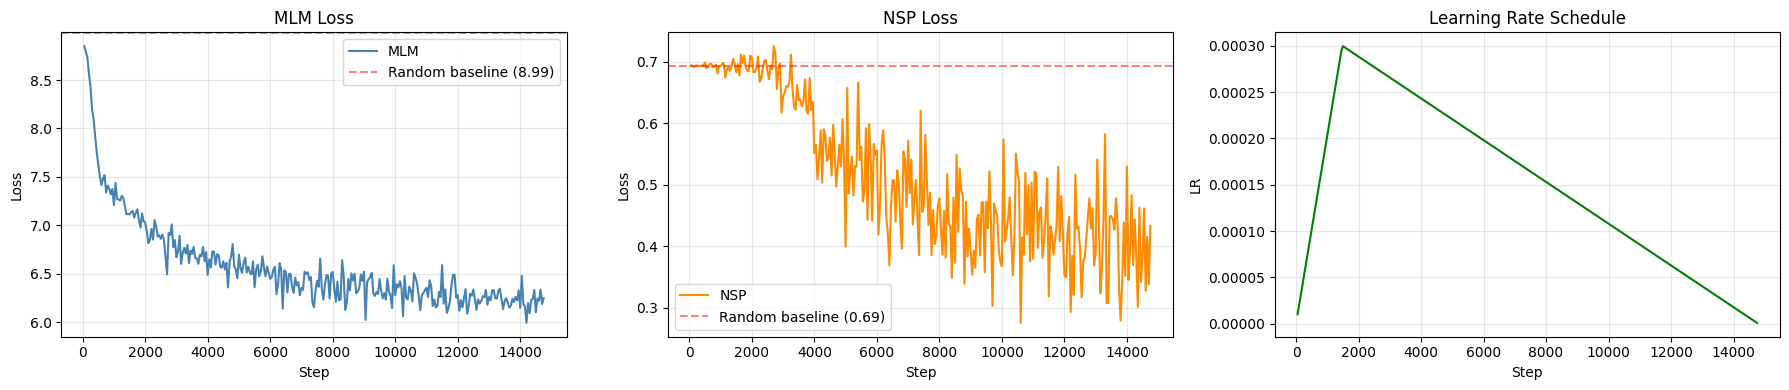

학습 시작 → 종료 (시작 / 끝 값):
  MLM:   8.850 → 6.248
  NSP:   0.694 → 0.433
  Total: 9.544 → 6.681

MLM 감소량: 2.602
NSP 감소량: 0.261


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Loss 그래프
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

steps = history['step']

# MLM Loss
axes[0].plot(steps, history['mlm_loss'], label='MLM', color='steelblue')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('MLM Loss')
axes[0].axhline(y=np.log(config.vocab_size), color='red', linestyle='--', alpha=0.5, label=f'Random baseline ({np.log(config.vocab_size):.2f})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# NSP Loss
axes[1].plot(steps, history['nsp_loss'], label='NSP', color='darkorange')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Loss')
axes[1].set_title('NSP Loss')
axes[1].axhline(y=np.log(2), color='red', linestyle='--', alpha=0.5, label=f'Random baseline ({np.log(2):.2f})')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Learning rate
axes[2].plot(steps, history['lr'], color='green')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('LR')
axes[2].set_title('Learning Rate Schedule')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 수치 요약
print("=" * 50)
print(f"학습 시작 → 종료 (시작 / 끝 값):")
print(f"  MLM:   {history['mlm_loss'][0]:.3f} → {history['mlm_loss'][-1]:.3f}")
print(f"  NSP:   {history['nsp_loss'][0]:.3f} → {history['nsp_loss'][-1]:.3f}")
print(f"  Total: {history['total_loss'][0]:.3f} → {history['total_loss'][-1]:.3f}")
print(f"\nMLM 감소량: {history['mlm_loss'][0] - history['mlm_loss'][-1]:.3f}")
print(f"NSP 감소량: {history['nsp_loss'][0] - history['nsp_loss'][-1]:.3f}")

### MLM 빈칸 채우기 검증 

1차 결과 - 이상함 

모든 [MASK] 위치에서 topk-5 가 [PAD], [UNK], [CLS], [SEP], [MASK]만 나옴.
logit  값도 확인했는데 값들이 3천 이상으로 나와서 학습이 제대로 됬나 조금씩 진단을 시작했다.  

In [ ]:
import torch

def fill_mask(model, tokenizer, text, top_k=5):
    model.eval()
    
    cls_id = tokenizer.piece_to_id('[CLS]')
    sep_id = tokenizer.piece_to_id('[SEP]')
    mask_id = tokenizer.piece_to_id('[MASK]')
    
    # 토큰화 (이미 [MASK]가 들어있는 문장)
    pieces = tokenizer.encode_as_pieces(text)
    ids = []
    for p in pieces:
        if p == '[MASK]':
            ids.append(mask_id)
        else:
            ids.append(tokenizer.piece_to_id(p))
    
    # [CLS] ... [SEP] 형태로 감싸기
    input_ids = [cls_id] + ids + [sep_id]
    seq_len = len(input_ids)
    
    # 텐서 변환
    input_ids_t = torch.tensor([input_ids], device=device)
    segment_ids_t = torch.zeros(1, seq_len, dtype=torch.long, device=device)
    attention_mask_t = torch.ones(1, seq_len, device=device)
    
    # Forward
    with torch.no_grad():
        mlm_logits, _ = model(input_ids_t, segment_ids_t, attention_mask_t)
    
    # [MASK] 위치 찾기
    mask_positions = [i for i, tid in enumerate(input_ids) if tid == mask_id]
    
    print(f"입력: {text}")
    print(f"토큰: {[tokenizer.id_to_piece(t) for t in input_ids]}")
    print()
    
    for pos in mask_positions:
        logits = mlm_logits[0, pos]  # (vocab_size,)
        top_values, top_indices = torch.topk(logits, top_k)
        probs = torch.softmax(top_values, dim=0)
        
        print(f"위치 {pos}의 [MASK] 예측 top-{top_k}:")
        for idx, (val, prob) in enumerate(zip(top_indices.tolist(), probs.tolist())):
            piece = tokenizer.id_to_piece(idx)
            print(f"  {idx+1}. {piece:>15s}  (logit={val:.2f}, prob={prob:.3f})")
        print()


# 테스트 문장들
test_cases = [
    "대한[MASK]은 동아시아에 위치한 나라이다.",
    "[MASK]는 양방향 언어 모델이다.",
    "그는 학교[MASK] 갔다.",
    "지구는 태양의 [MASK] 행성이다.",
    "오늘 날씨가 [MASK] 좋다.",
]

for text in test_cases:
    fill_mask(model, sp, text)
    print("=" * 60)

입력: 대한[MASK]은 동아시아에 위치한 나라이다.
토큰: ['[CLS]', '▁대한', '[MASK]', '은', '▁동', '아시아', '에', '▁위치한', '▁나라', '이다', '.', '[SEP]']

위치 2의 [MASK] 예측 top-5:
  1.           [PAD]  (logit=125.00, prob=0.255)
  2.           [UNK]  (logit=3824.00, prob=0.219)
  3.           [CLS]  (logit=276.00, prob=0.211)
  4.           [SEP]  (logit=5.00, prob=0.160)
  5.          [MASK]  (logit=57.00, prob=0.156)

입력: [MASK]는 양방향 언어 모델이다.
토큰: ['[CLS]', '▁', '[MASK]', '는', '▁양', '방', '향', '▁언어', '▁모델', '이다', '.', '[SEP]']

위치 2의 [MASK] 예측 top-5:
  1.           [PAD]  (logit=3824.00, prob=0.388)
  2.           [UNK]  (logit=3812.00, prob=0.164)
  3.           [CLS]  (logit=1135.00, prob=0.157)
  4.           [SEP]  (logit=3816.00, prob=0.148)
  5.          [MASK]  (logit=3813.00, prob=0.142)

입력: 그는 학교[MASK] 갔다.
토큰: ['[CLS]', '▁그는', '▁학교', '[MASK]', '▁', '갔다', '.', '[SEP]']

위치 3의 [MASK] 예측 top-5:
  1.           [PAD]  (logit=3824.00, prob=0.403)
  2.           [UNK]  (logit=168.00, prob=0.188)
  3.           [CLS]  (

### 진단 

모델결과가 이상했을 때 두가지 정도를 의심했었다. 
하나는 모델 자체의 문제 - 학습이 제대로 안됬거나 weight tying이 잘못 작동 되었거나 하는 경우였다. 
그리고 아래를 통해 모델 자체는 정상적이라는 것을 확인 한 뒤 모델은 멀쩡하지만 다른쪽으로 문제가 있다는 것을 의심했다. 
- 변수가 꼬이던지, 단위나 인덱싱의 실수 

검증은 
우선 bias를 구하는것부터 시작했다. bias는 보캡에 각각 더해지는 보정값인데 학습이 망가졌다면 이 값이 폭주한다는 ai를 통해 알수 있었기 때문이다. 정상값은 0근처에서 존재함
두번째는 토큰 임베딩의 통계값이었다. 이것은 weight tying을 했기 때문에 각 텐서의 값들이 정상적인지를 확인한다면 바로 알수 있을 것이었기 때문이다. 초기화된 ㄹ랜덤분포에서의 거리차이를 통해 추론을 해봤으며 살짝 학습된 상태를 봤을 때 정상이라 판단했다. 
나머지는 특수 토큰 ID의 bias 직접 확인이었다. 이것 역시 초반의 bias와 비슷한 맥락에서 의심을 했는데 
정말로 특수토큰만 추론을 했다면 아마 이 bias값이 엄청 높게 잡혔을 것이기 때문이다. 
생각해보면 특수토큰의 임베딩을 확인하는 것도 방법이었을것 같기도 하다. 



- mlm_head bias: mean -0.04, std 0.06 (정상 범위)
- token embedding: std 0.046, max 0.22 (초기화 분포 유지)
- 특수 토큰 bias가 오히려 -1.0대로 낮음 (의도대로)
→ 모델은 정상.

진짜 원인 — 디버깅 함수의 변수 꼬임
출력 함수에서 enumerate의 인덱스(0~4)를 vocab ID로 잘못 사용했고,
실제 vocab ID(top_indices)를 logit 값처럼 출력하고 있었다.
그래서 항상 ID 0~4의 piece(=특수 토큰 5개)가 출력됐고,
"logit 3824"는 사실 logit이 아니라 vocab ID였다.




In [25]:
model.eval()

# 1. MLM head bias 확인
print("=" * 50)
print("MLM head bias 통계:")
bias = model.mlm_head.bias
print(f"  shape: {bias.shape}")
print(f"  mean:  {bias.mean().item():.4f}")
print(f"  std:   {bias.std().item():.4f}")
print(f"  max:   {bias.max().item():.4f}")
print(f"  min:   {bias.min().item():.4f}")
print()
print("Top 10 bias (가장 큰 값):")
top_bias_vals, top_bias_idx = torch.topk(bias, 10)
for v, i in zip(top_bias_vals.tolist(), top_bias_idx.tolist()):
    piece = sp.id_to_piece(i)
    print(f"  ID {i:>5} ({piece:>10s}): bias = {v:.2f}")

# 2. Token embedding (= mlm_head.weight) 통계
print("\n" + "=" * 50)
print("Token embedding (= mlm_head.weight) 통계:")
W = model.embedding.token_embedding.weight
print(f"  shape: {W.shape}")
print(f"  mean:  {W.mean().item():.4f}")
print(f"  std:   {W.std().item():.4f}")
print(f"  max:   {W.max().item():.4f}")
print(f"  min:   {W.min().item():.4f}")

# 3. weight tying 확인
print("\n" + "=" * 50)
print("Weight tying 확인:")
is_same = (model.mlm_head.weight is model.embedding.token_embedding.weight)
print(f"  같은 텐서인가? {is_same}")

# 4. 특정 vocab의 logit 계산 직접
print("\n" + "=" * 50)
print("특수 토큰 ID의 bias만 보기:")
for piece in ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']:
    pid = sp.piece_to_id(piece)
    print(f"  {piece:>8s} (ID {pid:>3}): bias = {bias[pid].item():.2f}")

MLM head bias 통계:
  shape: torch.Size([8000])
  mean:  -0.0391
  std:   0.0576
  max:   0.1340
  min:   -1.3556

Top 10 bias (가장 큰 값):
  ID  3837 (         )): bias = 0.13
  ID  3838 (         (): bias = 0.12
  ID  3808 (         ▁): bias = 0.10
  ID  3810 (         다): bias = 0.09
  ID  3816 (         ,): bias = 0.09
  ID    15 (        ▁수): bias = 0.09
  ID  3812 (         의): bias = 0.09
  ID  3839 (         년): bias = 0.09
  ID  3817 (         을): bias = 0.08
  ID  3809 (         이): bias = 0.08

Token embedding (= mlm_head.weight) 통계:
  shape: torch.Size([8000, 128])
  mean:  0.0001
  std:   0.0465
  max:   0.2169
  min:   -0.2489

Weight tying 확인:
  같은 텐서인가? True

특수 토큰 ID의 bias만 보기:
     [PAD] (ID   0): bias = -0.08
     [UNK] (ID   1): bias = -0.73
     [CLS] (ID   2): bias = -1.23
     [SEP] (ID   3): bias = -1.13
    [MASK] (ID   4): bias = -1.36


### 2차 결과 — 함수 수정 후

정상적인 2차 결과를 통해서 모델의 출력을 확인해봤다. 
topk-5개의 후보를 통해 모델이 얼마나 [MASK]에 근접한 값을 출력하는지 눈으로 직접 확인해보는 것이었는데 생각보다 결과는 좋지 않았다. 
적중율도 문제였지만 대부분이 부사나 조사같은 연결어들이 top5를 전부 차지하고 있었기 때문이다. 
하지만 생각해보면 이상한 일이었다. 만약 학습이 제대로 되지 않았다면 조사나 부사가 아닌 완전히 다른 단어가 나오지 않았을까 하는 생각이 들었기 때문이다. 



In [ ]:
def fill_mask(model, tokenizer, text, top_k=5):
    model.eval()
    
    cls_id = tokenizer.piece_to_id('[CLS]')
    sep_id = tokenizer.piece_to_id('[SEP]')
    mask_id = tokenizer.piece_to_id('[MASK]')
    
    pieces = tokenizer.encode_as_pieces(text)
    ids = []
    for p in pieces:
        if p == '[MASK]':
            ids.append(mask_id)
        else:
            ids.append(tokenizer.piece_to_id(p))
    
    input_ids = [cls_id] + ids + [sep_id]
    seq_len = len(input_ids)
    
    input_ids_t = torch.tensor([input_ids], device=device)
    segment_ids_t = torch.zeros(1, seq_len, dtype=torch.long, device=device)
    attention_mask_t = torch.ones(1, seq_len, device=device)
    
    with torch.no_grad():
        mlm_logits, _ = model(input_ids_t, segment_ids_t, attention_mask_t)
    
    mask_positions = [i for i, tid in enumerate(input_ids) if tid == mask_id]
    
    print(f"입력: {text}")
    print(f"토큰: {[tokenizer.id_to_piece(t) for t in input_ids]}")
    print()
    
    for pos in mask_positions:
        logits = mlm_logits[0, pos]  # (vocab_size,)
        top_values, top_indices = torch.topk(logits, top_k)
        
        # 전체 vocab에 대한 softmax 
        full_probs = torch.softmax(logits, dim=0)
        
        print(f"위치 {pos}의 [MASK] 예측 top-{top_k}:")
        for rank, (logit_val, vocab_id) in enumerate(zip(top_values.tolist(), top_indices.tolist())):
            piece = tokenizer.id_to_piece(vocab_id)   # ← 진짜 vocab_id로!
            prob = full_probs[vocab_id].item()         # ← 전체 prob에서 추출
            print(f"  {rank+1}. {piece:>15s}  (id={vocab_id}, logit={logit_val:.2f}, prob={prob:.4f})")
        print()


test_cases = [
    "대한[MASK]은 동아시아에 위치한 나라이다.",
    "[MASK]는 양방향 언어 모델이다.",
    "그는 학교[MASK] 갔다.",
    "지구는 태양의 [MASK] 행성이다.",
    "오늘 날씨가 [MASK] 좋다.",
]

for text in test_cases:
    fill_mask(model, sp, text)
    print("=" * 60)

입력: 대한[MASK]은 동아시아에 위치한 나라이다.
토큰: ['[CLS]', '▁대한', '[MASK]', '은', '▁동', '아시아', '에', '▁위치한', '▁나라', '이다', '.', '[SEP]']

위치 2의 [MASK] 예측 top-5:
  1.              ▁역  (id=125, logit=5.16, prob=0.0111)
  2.               은  (id=3824, logit=5.00, prob=0.0096)
  3.              ▁산  (id=276, logit=4.96, prob=0.0092)
  4.              ▁이  (id=5, logit=4.69, prob=0.0070)
  5.              ▁동  (id=57, logit=4.66, prob=0.0068)

입력: [MASK]는 양방향 언어 모델이다.
토큰: ['[CLS]', '▁', '[MASK]', '는', '▁양', '방', '향', '▁언어', '▁모델', '이다', '.', '[SEP]']

위치 2의 [MASK] 예측 top-5:
  1.               은  (id=3824, logit=5.06, prob=0.0137)
  2.               의  (id=3812, logit=4.19, prob=0.0058)
  3.              어는  (id=1135, logit=4.15, prob=0.0055)
  4.               ,  (id=3816, logit=4.10, prob=0.0052)
  5.               는  (id=3813, logit=4.05, prob=0.0050)

입력: 그는 학교[MASK] 갔다.
토큰: ['[CLS]', '▁그는', '▁학교', '[MASK]', '▁', '갔다', '.', '[SEP]']

위치 3의 [MASK] 예측 top-5:
  1.               은  (id=3824, logit=6.26, prob=0.0

### 임베딩 차원을 확인 

Embedding shape: (8000, 128)
  [SKIP] '▁머리' → UNK (vocab에 없음)
  [SKIP] '▁간다' → UNK (vocab에 없음)

검증할 단어 수: 47
선택된 임베딩 shape: (47, 128)

PCA 계산 중...
PCA explained variance: [0.17898865 0.08917291]
t-SNE 계산 중...


C:\Users\akals\AppData\Local\Temp\ipykernel_44520\2328236654.py:78: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\akals\AppData\Local\Temp\ipykernel_44520\2328236654.py:78: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\akals\AppData\Local\Temp\ipykernel_44520\2328236654.py:78: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\akals\AppData\Local\Temp\ipykernel_44520\2328236654.py:78: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\akals\AppData\Local\Temp\ipykernel_44520\2328236654.py:78: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\akals\AppData\Local\Temp\ipykernel_44520\2328236654.py:78: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from

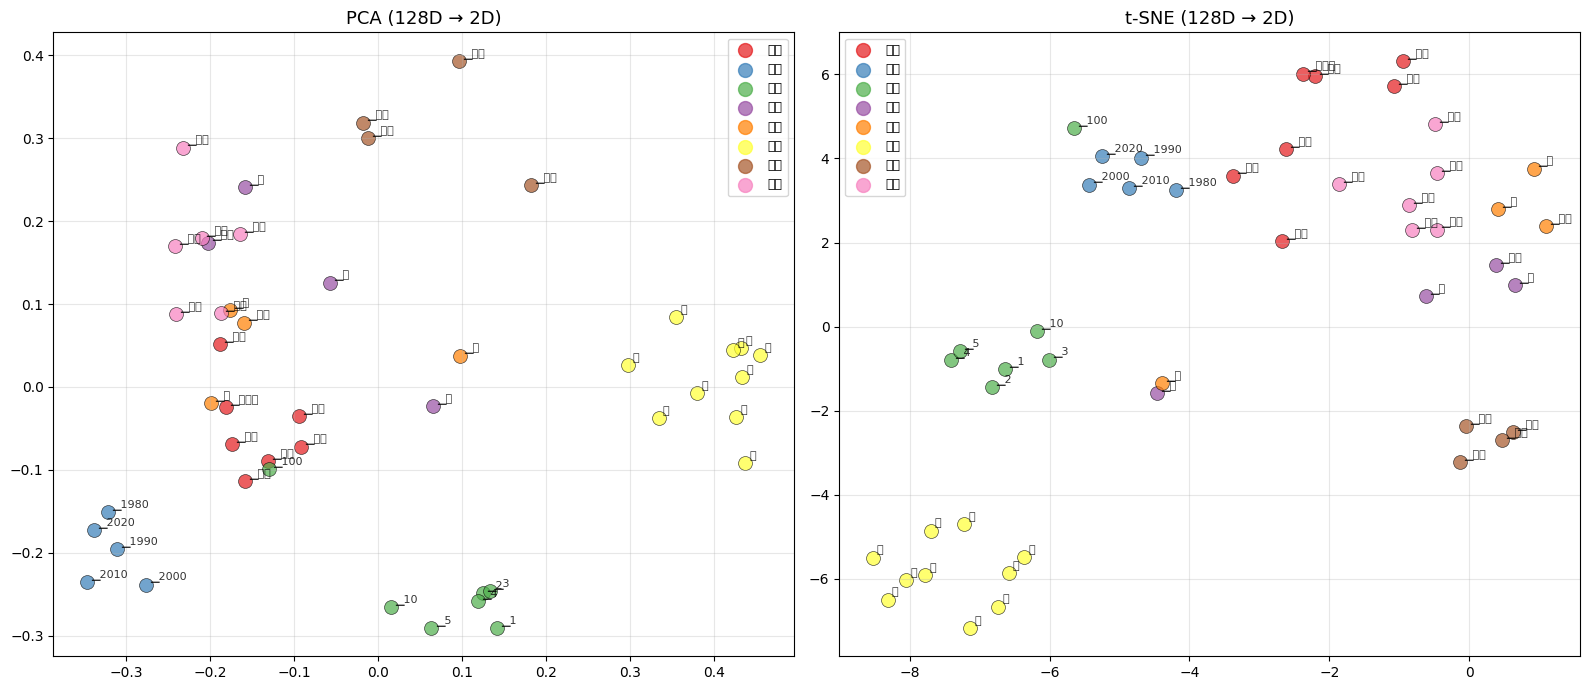


그룹 내 vs 그룹 간 cosine similarity:
  같은 그룹 내 평균 유사도: 0.3454
  다른 그룹 간 평균 유사도: 0.0212
  차이: 0.3241

(차이가 클수록 의미 학습이 잘 된 것)
(완전 랜덤이면 차이 ≈ 0, 잘 학습되면 0.1~0.3 정도)


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# 1. Token embedding 추출
embeddings = model.embedding.token_embedding.weight.detach().cpu().numpy()
print(f"Embedding shape: {embeddings.shape}")  # (8000, 128)

# 2. 의미 그룹별 단어 선정 
word_groups = {
    '국가': ['▁한국', '▁미국', '▁중국', '▁일본', '▁독일', '▁영국', '▁프랑스'],
    '연도': ['▁2000', '▁2010', '▁2020', '▁1990', '▁1980'],
    '숫자': ['▁1', '▁2', '▁3', '▁4', '▁5', '▁10', '▁100'],
    '신체': ['▁머리', '▁얼굴', '▁손', '▁발', '▁눈'],
    '시간': ['▁년', '▁월', '▁일', '▁시간'],
    '조사': ['은', '는', '이', '가', '을', '를', '의', '에', '와', '과'],
    '동사': ['▁있다', '▁없다', '▁된다', '▁한다', '▁간다'],
    '학문': ['▁수학', '▁과학', '▁역사', '▁철학', '▁음악', '▁문학'],
}

# 3. 각 단어의 ID와 임베딩 추출
selected_words = []
selected_ids = []
selected_groups = []
group_colors = {}
colors_palette = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33', '#a65628', '#f781bf']

for color, (group, words) in zip(colors_palette, word_groups.items()):
    group_colors[group] = color
    for w in words:
        wid = sp.piece_to_id(w)
        if wid == sp.unk_id():
            print(f"  [SKIP] '{w}' → UNK (vocab에 없음)")
            continue
        selected_words.append(w)
        selected_ids.append(wid)
        selected_groups.append(group)

print(f"\n검증할 단어 수: {len(selected_words)}")

# 4. 임베딩 추출
selected_embeddings = embeddings[selected_ids]
print(f"선택된 임베딩 shape: {selected_embeddings.shape}")

# 5. 2D 차원 축소 (t-SNE + PCA 둘 다)
print("\nPCA 계산 중...")
pca = PCA(n_components=2)
embed_pca = pca.fit_transform(selected_embeddings)
print(f"PCA explained variance: {pca.explained_variance_ratio_}")

print("t-SNE 계산 중...")
tsne = TSNE(n_components=2, perplexity=min(15, len(selected_words)-1), random_state=42, init='pca')
embed_tsne = tsne.fit_transform(selected_embeddings)

# 6. 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, embed_2d, title in [
    (axes[0], embed_pca, 'PCA (128D → 2D)'),
    (axes[1], embed_tsne, 't-SNE (128D → 2D)'),
]:
    for i, (word, group) in enumerate(zip(selected_words, selected_groups)):
        ax.scatter(embed_2d[i, 0], embed_2d[i, 1], 
                   c=group_colors[group], s=100, alpha=0.7,
                   edgecolors='black', linewidths=0.5)
        ax.annotate(word, (embed_2d[i, 0], embed_2d[i, 1]),
                    fontsize=8, alpha=0.8, xytext=(3, 3), textcoords='offset points')
    
    # 범례
    for group, color in group_colors.items():
        ax.scatter([], [], c=color, label=group, s=100, alpha=0.7)
    ax.legend(loc='best', fontsize=9)
    ax.set_title(title, fontsize=13)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 7. 정량 평가 — 같은 그룹 내 vs 그룹 간 거리
print("\n" + "=" * 50)
print("그룹 내 vs 그룹 간 cosine similarity:")

def cos_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

import itertools

intra_group_sims = []  # 같은 그룹 내
inter_group_sims = []  # 다른 그룹 간

for i, j in itertools.combinations(range(len(selected_words)), 2):
    sim = cos_sim(selected_embeddings[i], selected_embeddings[j])
    if selected_groups[i] == selected_groups[j]:
        intra_group_sims.append(sim)
    else:
        inter_group_sims.append(sim)

print(f"  같은 그룹 내 평균 유사도: {np.mean(intra_group_sims):.4f}")
print(f"  다른 그룹 간 평균 유사도: {np.mean(inter_group_sims):.4f}")
print(f"  차이: {np.mean(intra_group_sims) - np.mean(inter_group_sims):.4f}")
print()
print("(차이가 클수록 의미 학습이 잘 된 것)")
print("(완전 랜덤이면 차이 ≈ 0, 잘 학습되면 0.1~0.3 정도)")

### 임베딩 차원 분포 분석 + 회고 

학습이 제대로 됐다면 아마 의미적으로 비슷한 단어들이 임베딩 공간에서 가까이 모여있지 않을까 하는 생각을 했다. 
만약 학습이 제대로 되지 않는다면 분포가 제대로 이뤄지지 않았을 테고 말이다. 

만약 분포가 이뤄졌으면 그건 학습은 제대로 이뤄지고 있다는 것으로 받아들이고 학습 외, 하이퍼 파라미터나 학습 방식 같은 부분에서의 
개선점을 찾아보려고 했다. 
하지만 그래프의 가시화를 보면 생각보다 분포가 군집을 이루고 있는것을 확인했는데 

연도, 숫자, 조사 등이 각자 명확한 클러스터를 형성하고 있었다는 점이 특징이었다. 
그렇다면 학습은 제대로 되고 있다고 생각하기로 한다. 
임베딩에서 분포가 일어났다는건 표현학습의 근본은 작동하고 있었기 때문이니까 

결국 학습 방법이 틀리지 않았다면 부족한건 양적인 문제가 아니었을까. 
1M정도의 작은 모델의 크기나, 혹은 2에폭 정도의 작은 학습 횟수가 미흡했기 때문에가 아니었을 까 라는 생각을 하게 되었다. 
보캡 사이즈가 작기도 했기 때문에 각 헤드 어텐션이 토큰간의 상관관계를 제대로 잡지 못했을 수도 있을지도 모르고 말이다. 

하지만 학습 횟수를 올린다고 하더라도 아마 큰 변화는 보지 못할것이라고 생각해서 학습은 더 이상진행하지 않기로 했다. 

하지만 임베딩 차원에서의 의미있는 분포가 생기는데 왜 MLM에서의 토큰 예측은 실패했는지는 조금 이상한 일이었다. 





**왜 임베딩은 학습됐는데 MLM 빈칸 채우기는 실패했나**:

두 작업이 사실 다른 수준의 학습을 요구한다.
- 임베딩 학습 = "이 단어가 어떤 부류인가" (카테고리화, 상대적 위치)
- MLM 빈칸 채우기 = "8000개 중 정확히 어떤 단어인가" (fine-grained 식별, 절대적 점)

128차원이라는 표현 공간은 카테고리 10개 정도 분리하기엔 충분해도, 
8000개 vocab을 정밀하게 배치하기엔 좁다.
log₂(8000) ≈ 13 bits를 풀어내려면 더 큰 hidden dimension이 필요하다.

또한 mlm_head 자체가 단일 선형 변환(Linear(128, 8000))이라,
임베딩 공간에서 비슷한 위치에 있는 단어들의 logit이 자연스럽게 비슷해진다.
"조사 카테고리"에서 "은/는/이/가/의" logit이 모두 가까운 값을 가져 top 5에 몰리는 이유.

큰 BERT는 hidden 768차원 + mlm_head가 768→30000로 풍부해서 fine-grained 식별까지 가능하지만,
우리 1.86M 모델은 카테고리화까지는 성공했고 그 다음 단계가 표현력 한계로 막힌 것.

결론: 학습 방식이 틀린 게 아니라, **모델 크기(특히 hidden_dim)**가 부족했다.
같은 학습 코드로 hidden_dim 256~512로 키우면 MLM 빈칸 채우기도 잘 될 가능성이 높다.